# constructing 2D/3D local box using GeoPoints.jl 

Nobuaki Fuji (IPGP/UPC/IUF) December 2025

todo: normals computations for each point, SeisTomoPy 


you can also see how to use lazyProduceOrLoad, which is not safe solution but when debugging, it's cool! (but don't write a biiiig jdl2 neither!)

In [1]:

using Pkg

cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv" # 1D Earth/Mars/Moon models are defined

include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

using .commonBatchs, .planet1D, .GeoPoints
using Colors



  Activating project at `~/Documents/Github/flexOPT`


In [2]:
set_default_planet!(:Earth) # if you wish to go to other telluric bodies, otherwise this is not necessary

Ellipsoid(Earth)

In [3]:
p1 = GeoPoint(43.6047,1.4447) # Toulouse (latitude, longitude)
p2 = GeoPoint(42.8485,1.6048) # Tarascon (à peu près)


GeoPoint(42.8485, 1.6048, 0.0, [4.681578312996181e6, 131160.83282794568, 4.315177677165435e6], 6.3682915330794295e6)

In [4]:
Δx = 500.0 # in metre
Δy = 500.0
Δz = 500.0

altMax = 10.e3 # in metre
altMin = -100.e3 # in metre

horizontalDepth = 50.e3

50000.0

In [5]:
set_default_planet!(:Earth) 
# two (extreme) points that can define the slice (or the x-y local plane for 3D box)
p1 = GeoPoint(48.8566,2.3522) # Paris (latitude, longitude)
p2 = GeoPoint(42.8,1.5) # Tarascon (à peu près)


Δx = 100.0 # in metre
Δz = 100.0

altMax = 10.e3 # in metre
altMin = -100.e3 # in metre

# altMax and altMin are measured from the middle point at p1 and p2 (but the planet's surface normally), the user can change the option hidden in constructLocalBox

-100000.0

In [6]:
@show p1 # GeoPoint has some attributes

p1 = GeoPoint(48.8566, 2.3522, 0.0, [4.200914795649138e6, 172559.77631070156, 4.780081341967356e6], 6.366053693814456e6)


GeoPoint(48.8566, 2.3522, 0.0, [4.200914795649138e6, 172559.77631070156, 4.780081341967356e6], 6.366053693814456e6)

In [7]:
# make a box/rectangle

boxGrids=constructLocalBox(p1,p2,Δx,Δz,altMin,altMax)
#allGridsInGeoPoints, allGridsInCartesian, effectiveRadii=lazyProduceOrLoad("boxGrids",constructLocalBox,p1,p2,Δx,Δz,altMin,altMax) <- don't do this, it's too heavy


(allGridsInGeoPoints = GeoPoint[GeoPoint(48.902921501041355, 2.3590224318717534, -89745.1594792945, [4.1380740743336356e6, 170472.05638725864, 4.7158373711397825e6], 6.276291889142796e6) GeoPoint(48.9028695608542, 2.359014732850996, -89645.32331843738, [4.1381439556224435e6, 170474.37821651908, 4.715908863898741e6], 6.276391743962576e6) … GeoPoint(48.846817661391015, 2.3507151908714294, 19977.871839904237, [4.214873610733294e6, 173023.74674448266, 4.794407913234886e6], 6.3860350774077885e6) GeoPoint(48.84676748811989, 2.3507077697726615, 20077.71358180186, [4.214943492022102e6, 173026.06857374308, 4.794479405993844e6], 6.386134937177936e6); GeoPoint(48.90201580658621, 2.358879698228112, -89750.88059870013, [4.1381455109377312e6, 170464.6729623241, 4.715767784527338e6], 6.276286503340023e6) GeoPoint(48.90196388072739, 2.358872001748998, -89651.04434692362, [4.138215392226539e6, 170466.99479158456, 4.715839277286297e6], 6.276386358245488e6) … GeoPoint(48.84592744594503, 2.350575197069019

In [8]:
boxGrids.allGridsInGeoPoints[1,1,1]

GeoPoint(48.902921501041355, 2.3590224318717534, -89745.1594792945, [4.1380740743336356e6, 170472.05638725864, 4.7158373711397825e6], 6.276291889142796e6)

In [9]:
boxGrids.allGridsInCartesian[20,30]

localCoord2D(Integer[20, 30], [-336148.5156153419, -97100.0], [0.9985657371009425, 0.05353941247391099], [-0.053539412473905104, 0.9985657371008327])

In [10]:
#seismicModel=getParamsAndTopo(allGridsInGeoPoints,effectiveRadii,2.0) # this can be also GPUed
seismicModel=lazyProduceOrLoad("seismicModel",getParamsAndTopo,boxGrids.allGridsInGeoPoints,boxGrids.effectiveRadii,2.0)
#seismicModel=lazyProduceOrLoad("seismicModel") # this is the laziest way to load

Loading from ./tmp/seismicModel.jld2


(ρ = [3.373638950281932 3.3736498088987372 … 0.0 0.0; 3.373638328544274 3.373649187170389 … 0.0 0.0; … ; 3.3733922132521563 3.3734030718802077 … 0.0 0.0; 3.373392762364162 3.373403620982897 … 0.0 0.0], Vpv = [7.9479448629910285 7.948058059836924 … 0.0 0.0; 7.947938381618389 7.948051578561335 … 0.0 0.0; … ; 7.94537272567023 7.945485922633359 … 0.0 0.0; 7.9453784499487625 7.945491646814775 … 0.0 0.0], Vph = [8.142909418315625 8.142981827913417 … 0.0 0.0; 8.14290527232037 8.142977681980245 … 0.0 0.0; … ; 8.141264077163285 8.141336486836071 … 0.0 0.0; 8.141267738861655 8.141340148472317 … 0.0 0.0], Vsv = [4.411092184829838 4.411069165942278 … 0.0 0.0; 4.411093502834654 4.411070483927359 … 0.0 0.0; … ; 4.411615235974125 4.411592217062726 … 0.0 0.0; 4.411614071926462 4.411591053034812 … 0.0 0.0], Vsh = [4.553096623529719 4.553186290236021 … 0.0 0.0; 4.553091489434927 4.553181156218107 … 0.0 0.0; … ; 4.551059154376851 4.551148821176018 … 0.0 0.0; 4.551063688754094 4.551153355476332 … 0.0 0.0]

In [11]:
Nx,Nz=size(seismicModel.ρ)

(6761, 1101)

In [12]:
maximum(seismicModel.ρ)

3.3807411230672666

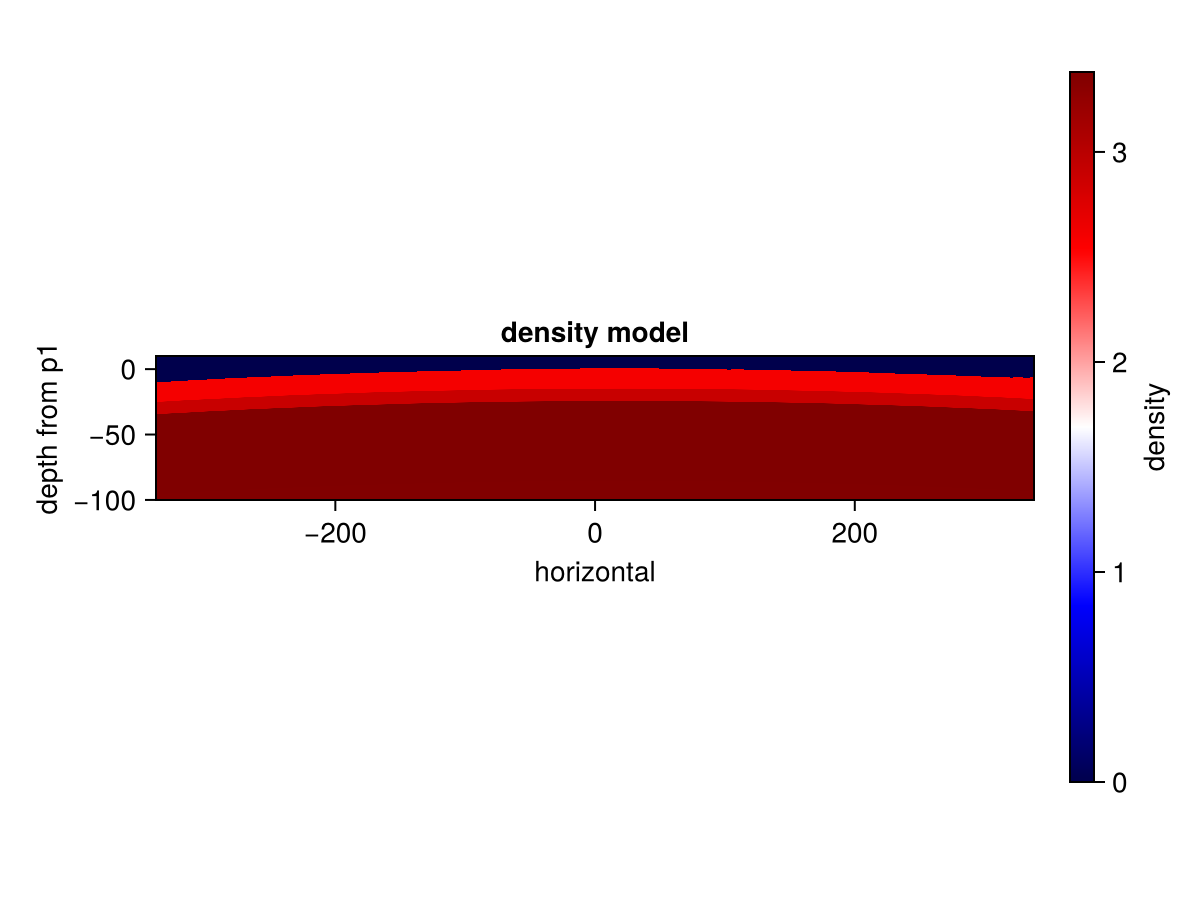

In [13]:
using CairoMakie
xvals = [p.xz[1] for p in boxGrids.allGridsInCartesian[:,1]]*1.e-3
zvals = [p.xz[2] for p in boxGrids.allGridsInCartesian[1,:]]*1.e-3
fig, ax, hm = heatmap(
    #topo.x,topo.y,topo.z';
    #collect((0:1:(Nx-1)).*Δx).*1.e-3,(collect(0:1:(Nz-1)).*Δz.+altMin).*1.e-3, seismicModel.ρ;
    xvals, zvals, seismicModel.ρ;
    colormap = :seismic,
    #colorrange=(0,4),
    axis = (aspect = DataAspect(), xlabel = "horizontal", ylabel = "depth from p1", title = "density model")
)
Colorbar(fig[1,2], hm, label="density")
fig

# if you want to put some 2D/3D perturbation into it (in percent or absolute value, as you wish)


In [14]:
imageFilePer="./myPerturbation.png"
modelPer= read2DimageModel(imageFilePer; Ncolor=256, colorbar = [RGB(1.0,0.0,0.0), RGB(1.0,1.0,1.0), RGB(0.0,0.0,1.0)] ,values = [-1.0,0.0,1.0],reverseOrNot=true,showRecoveredImage=false)
seismicModel=lazyProduceOrLoad("seismicModel")
# here is the size of the region to be perturbed
nx,nz=size(seismicModel.Vpv)
nx1,nz1 = round(Int,nx*0.1),round(Int,nz*0.1)
nx2,nz2 = round(Int,nx*0.9),round(Int,nz*0.9)
VpvSub = seismicModel.Vpv[nx1:nx2,nz1:nz2]
newPer = adjustArray(VpvSub,modelPer)
@. VpvSub = (1.0+0.2*newPer)*VpvSub # a very exaggerated model
seismicModel.Vpv[nx1:nx2,nz1:nz2]= VpvSub[1:end,1:end];

This is the laziest ProduceOrLoad
Loading from ./tmp/seismicModel.jld2


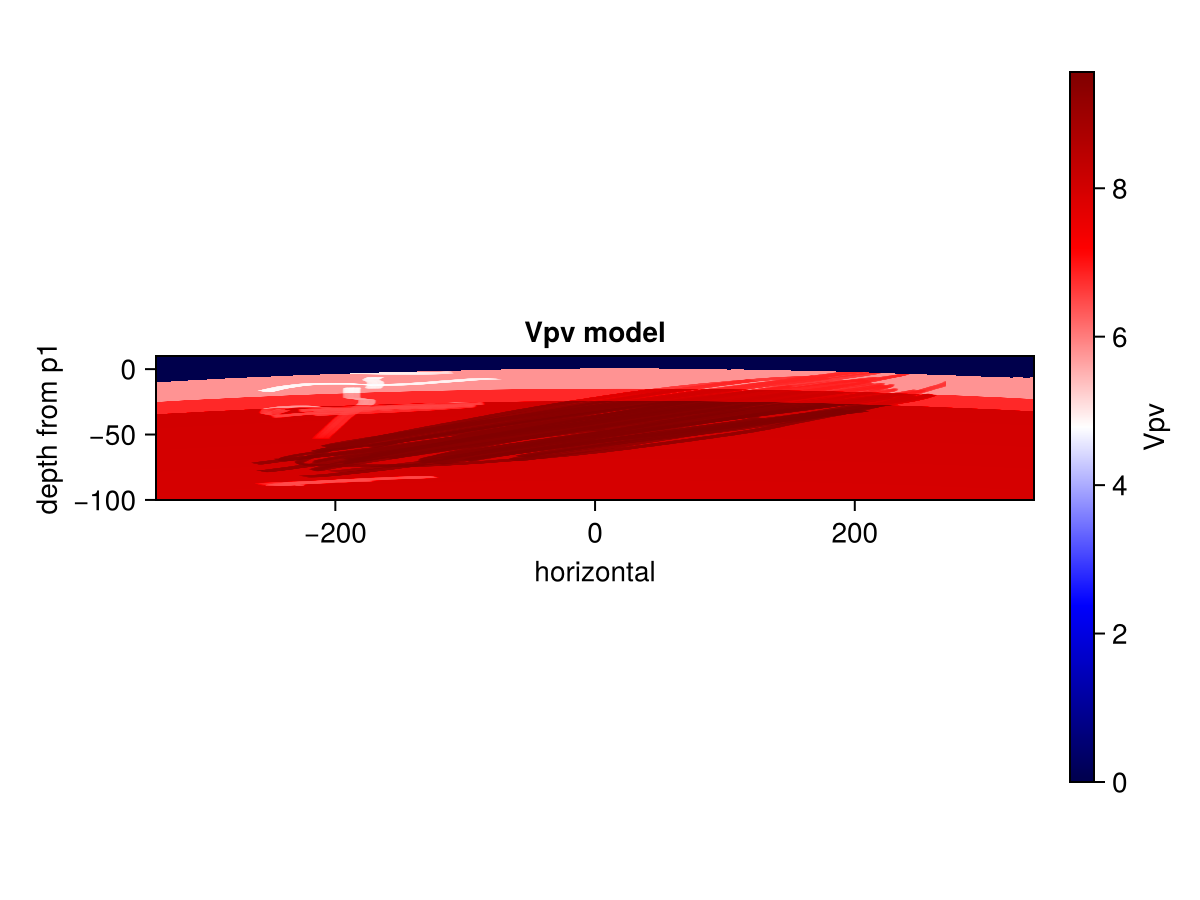

In [15]:
using CairoMakie
xvals = [p.xz[1] for p in boxGrids.allGridsInCartesian[:,1]]*1.e-3
zvals = [p.xz[2] for p in boxGrids.allGridsInCartesian[1,:]]*1.e-3
fig, ax, hm = heatmap(
    #topo.x,topo.y,topo.z';
    #collect((0:1:(Nx-1)).*Δx).*1.e-3,(collect(0:1:(Nz-1)).*Δz.+altMin).*1.e-3, seismicModel.ρ;
    xvals, zvals, seismicModel.Vpv;
    colormap = :seismic,
    #colorrange=(0,4),
    axis = (aspect = DataAspect(), xlabel = "horizontal", ylabel = "depth from p1", title = "Vpv model")
)
Colorbar(fig[1,2], hm, label="Vpv")
fig

# 3D box ? yes

In [16]:
p1 = GeoPoint(35.4139,138.2665) # 
p2 = GeoPoint(35.4172,139.2596) # 



Δx = 500.0 # in metre
Δy = 500.0
Δz = 500.0

altMax = 10.e3 # in metre
altMin = -300.e3 # in metre

horizontalDepth = 50.e3

# with theparameters below we can 'see' the topo 
#p1 = GeoPoint(35.538067,138.673722)
#p2 = GeoPoint(35.255127,138.675729)

#Δx = 100.0 # in metre
#Δy = 100.0
#Δz = 100.0

#altMax = 5.e3 # in metre
#altMin = -2.e3 # in metre

#horizontalDepth = 20.e3

50000.0

In [17]:

boxGrids3D=constructLocalBox(p1,p2,Δx,Δy,Δz,-horizontalDepth,horizontalDepth,altMin,altMax)

#ok 3D box version needs to be GPUed

(allGridsInGeoPoints = GeoPoint[GeoPoint(34.949740235547516, 138.2473228438806, -299791.8111941784, [-3.7211022824089294e6, 3.3215231568520544e6, 3.4615600250830906e6], 6.071368551233456e6) GeoPoint(34.95447001787269, 138.2472697027098, -299794.25542039017, [-3.7208840230019176e6, 3.321334535346357e6, 3.4619684179807263e6], 6.07136445417431e6) … GeoPoint(35.89088104087823, 138.23662526003227, -299465.05960081914, [-3.67766866041353e6, 3.283987477218262e6, 3.542830211712568e6], 6.071364462403614e6) GeoPoint(35.8956095268207, 138.23657087434225, -299459.29061520414, [-3.677450401006518e6, 3.2837988557125647e6, 3.5432386046102033e6], 6.07136855954588e6); GeoPoint(34.94978368849525, 138.25306592976114, -299795.48948076967, [-3.7214309864939675e6, 3.3211463931645094e6, 3.461561682860809e6], 6.071364857782577e6) GeoPoint(34.95451347618015, 138.2530131206535, -299797.933706664, [-3.7212127270869557e6, 3.320957771658812e6, 3.4619700757584446e6], 6.071360760720938e6) … GeoPoint(35.8909255658932

In [18]:
#seismicModel3D=getParamsAndTopo(allGridsInGeoPoints3D,effectiveRadii3D,2.0)
#seismicModel3D=lazyProduceOrLoad("seismicModel3D_Fuji_Floriane_topo_enhanced",getParamsAndTopo,boxGrids3D.allGridsInGeoPoints,boxGrids3D.effectiveRadii,2.0)
seismicModel3D=lazyProduceOrLoad("seismicModel3D_Fuji_Floriane",getParamsAndTopo,boxGrids3D.allGridsInGeoPoints,boxGrids3D.effectiveRadii,2.0)
#seismicModel3D=lazyProduceOrLoad("seismicModel3D")

Loading from ./tmp/seismicModel3D_Fuji_Floriane.jld2


(ρ = [3.48341798438645 3.4834194902678908 … 3.48323213329222 3.483228735044769; 3.483420181267312 3.4834216871492165 … 3.4832343299709927 3.4832309317210357; … ; 3.483420366600517 3.483421872402842 … 3.483234499444786 3.483231101115025; 3.4834181718019384 3.4834196776029076 … 3.4832323046701084 3.4832289063419597;;; 3.4831194259870486 3.4831209316669405 … 3.482933574761191 3.4829301767159775; 3.4831216226866983 3.483123128367052 … 3.482935771258779 3.482932373211056; … ; 3.4831218079486077 3.4831233135493886 … 3.4829359406625646 3.4829325425350475; 3.4831196133304414 3.4831211189298648 … 3.482933746068289 3.4829303479423834;;; 3.482820867584628 3.4828223730630024 … 3.482635016227164 3.4826316183841532; 3.4828230641030937 3.4828245695819304 … 3.4826372125435947 3.482633814698074; … ; 3.4828232492937192 3.4828247546929894 … 3.4826373818773884 3.482633983952079; 3.4828210548559357 3.4828225602538487 … 3.482635187463483 3.482631789539785;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0

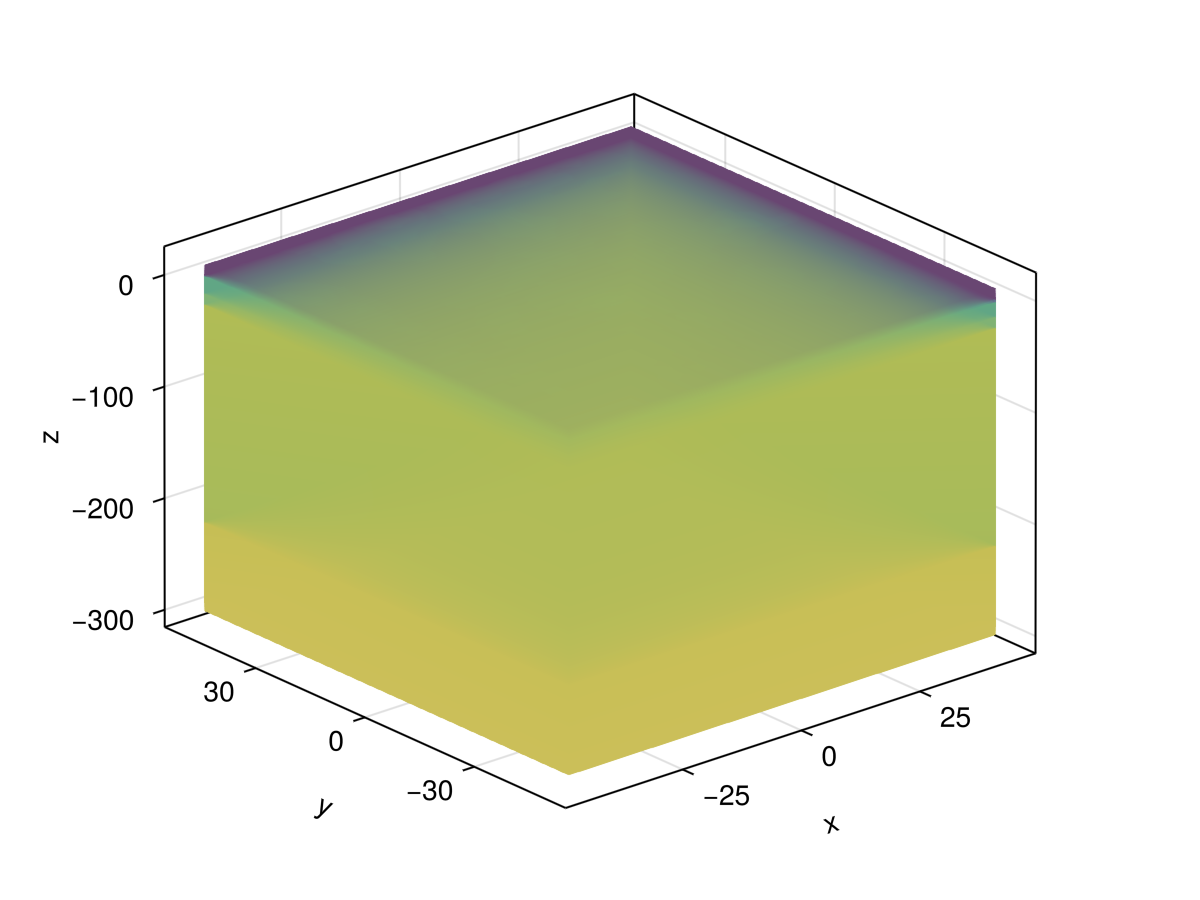

In [19]:
using GLMakie
GLMakie.activate!()
Makie.inline!() 
Nx3D,Ny3D,Nz3D=boxGrids3D.Nx, boxGrids3D.Ny, boxGrids3D.Nz

#x = (0:Nx3D-1) .* Δx .* 1e-3
#y = (0:Ny3D-1) .* Δy .* 1e-3 .- horizontalDepth*1.e-3
#z = (0:Nz3D-1) .* Δz .* 1e-3 .+ altMin*1.e-3

x = [p.xyz[1] for p in boxGrids3D.allGridsInCartesian[:,1,1]]*1.e-3
y = [p.xyz[2] for p in boxGrids3D.allGridsInCartesian[1,:,1]]*1.e-3
z = [p.xyz[3] for p in boxGrids3D.allGridsInCartesian[1,1,:]]*1.e-3
A = seismicModel3D.ρ

f = Figure()
ax = Axis3(f[1, 1])

volume!(ax,
    x[1] .. x[end],
    y[1] .. y[end],
    z[1] .. z[end],
    seismicModel3D.Vpv,
    algorithm = :absorption,   # optional, makes it nicer
    colormap = :viridis
)
f

In [20]:
size(boxGrids3D.allGridsInCartesian)

(181, 201, 621)

In [22]:
using CairoMakie

xvals = [p.xyz[1] for p in boxGrids3D.allGridsInCartesian[:,1,1]] .* 1e-3
zvals = [p.xyz[3] for p in boxGrids3D.allGridsInCartesian[1,1,590:621]] .* 1e-3

nx = length(xvals)
nz = length(zvals)

scale = 8

xmin, xmax = extrema(xvals)
zmin, zmax = extrema(zvals)

tmpCoordinates=[]
for i in 1:21

     
    yIndex = 10*(i-1)+1
    fig = Figure(resolution = (nx * scale, nz * scale))
    ax = Axis(fig[1, 1],
        aspect = DataAspect(),
        xlabel = "horizontal",
        ylabel = "depth from p1",
        title = "density model",
        xticks = xmin:20:xmax,
        yticks = zmin:10:zmax
    )

    tmpCoordinates=push!(tmpCoordinates,((boxGrids3D.allGridsInGeoPoints[1,yIndex,1].lat, boxGrids3D.allGridsInGeoPoints[1,yIndex,1].lon),
    (boxGrids3D.allGridsInGeoPoints[181,yIndex,1].lat, boxGrids3D.allGridsInGeoPoints[181,yIndex,1].lon)))
        

    hm = heatmap!(ax,
        xvals, zvals, seismicModel3D.ρ[:,yIndex,590:621];
        colormap = :seismic,
        interpolate = false
    )

    Colorbar(fig[1, 2], hm, label = "density")

    fig

    save("outputFuji_topo"*string(yIndex)*".png",fig)
end

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/nobuaki/.julia/packages/Makie/FUAHr/src/scenes.jl:238
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/nobuaki/.julia/packages/Makie/FUAHr/src/scenes.jl:238
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. U

In [23]:
tmpCoordinates[11:21]

11-element Vector{Any}:
 ((35.42270745654332, 138.2419781274021), (35.426173005128675, 139.28184558309962))
 ((35.470001662313756, 138.24144023425583), (35.47346920117908, 139.28191291734697))
 ((35.51729515185279, 138.24090171467242), (35.52076468327608, 139.28198033002607))
 ((35.56458786050311, 138.2403625675569), (35.568059386766535, 139.28204782127403))
 ((35.61187972361564, 138.23982279181186), (35.61535324700557, 139.28211539122827))
 ((35.659170676550055, 138.2392823863373), (35.66264619935706, 139.2821830400266))
 ((35.706460654675375, 138.2387413500307), (35.7099381791942, 139.2822507678071))
 ((35.75374959337041, 138.2381996817869), (35.75722912190001, 139.2823185747081))
 ((35.801037428024344, 138.2376573804982), (35.80451896286793, 139.28238646086842))
 ((35.84832409403728, 138.2371144450543), (35.85180763750227, 139.28245442642702))
 ((35.8956095268207, 138.23657087434225), (35.89909508121876, 139.28252247152332))

# another way of importing model parameters

## we can read images or cartoons

In [24]:
modelName="marmousi"
imageFile="../dataInput/model/random/marmousi.png"
modelDefinitionMethod="2DimageFile" # ToyModel or 2DimageFile (or 1DsphericalPlanet)
model=defineModel(imageFile);

model construction 

In [25]:
#
#boxGridsMarmousi = constructLocalBox(model,-3000.0,0.0,0.0,9200.0)
boxGridsMarmousi = lazyProduceOrLoad("MarmousiCoordInfo",constructLocalBox,model,-3000.0,0.0,0.0,9200.0)
#seismicModelMarmousi = makeAdHocSeismicModel(model, 1.0, 2.8, 1.5, 5.5, 0.0, 3.2)
seismicModelMarmousi=lazyProduceOrLoad("seismicModelMarmousi",makeAdHocSeismicModel,model, 1.0, 2.8, 1.5, 5.5, 0.0, 3.2)

#constructLocalBox for marmousi models should be written!

Loading from ./tmp/MarmousiCoordInfo.jld2
Loading from ./tmp/seismicModelMarmousi.jld2


(ρ = [2.170699554722287 2.0245474895931075 … 1.0 1.0; 2.177730255448793 2.047502416431925 … 1.0 1.0; … ; 2.3907335223245925 2.3517540751240253 … 1.0 1.0; 2.3907335223245925 2.3253749707054134 … 1.0 1.0], Vpv = [4.101554566049527 3.7767721990957948 … 1.5 1.5; 4.117178345441762 3.8277831476265005 … 1.5 1.5; … ; 4.590518938499095 4.503897944720057 … 1.5 1.5; 4.590518938499095 4.445277712678697 … 1.5 1.5], Vph = [4.101554566049527 3.7767721990957948 … 1.5 1.5; 4.117178345441762 3.8277831476265005 … 1.5 1.5; … ; 4.590518938499095 4.503897944720057 … 1.5 1.5; 4.590518938499095 4.445277712678697 … 1.5 1.5], Vsv = [2.081243652839622 1.8214177592766359 … 0.0 0.0; 2.09374267635341 1.8622265181012005 … 0.0 0.0; … ; 2.4724151507992755 2.4031183557760456 … 0.0 0.0; 2.4724151507992755 2.3562221701429578 … 0.0 0.0], Vsh = [2.081243652839622 1.8214177592766359 … 0.0 0.0; 2.09374267635341 1.8622265181012005 … 0.0 0.0; … ; 2.4724151507992755 2.4031183557760456 … 0.0 0.0; 2.4724151507992755 2.35622217014

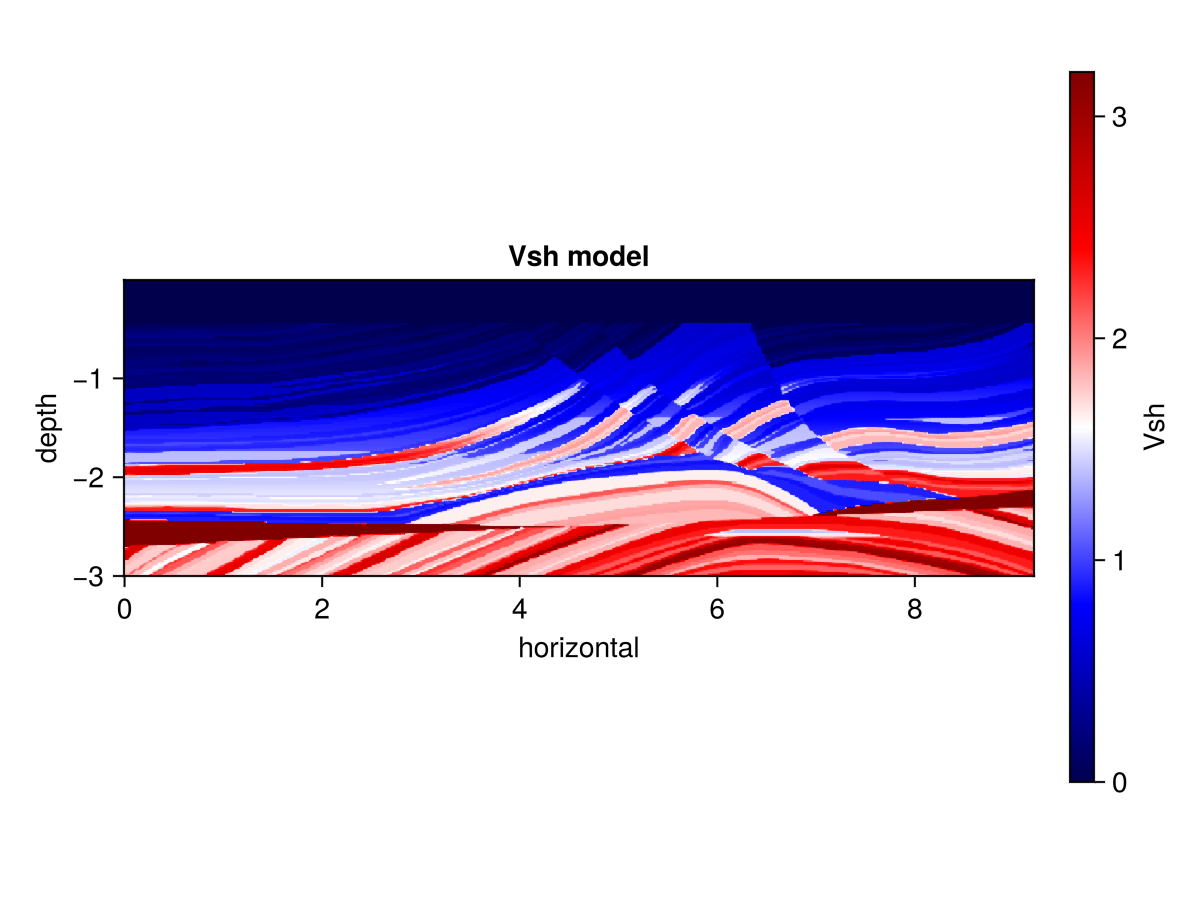

In [26]:
using CairoMakie
xvals = [p.xz[1] for p in boxGridsMarmousi.allGridsInCartesian[:,1]]*1.e-3
zvals = [p.xz[2] for p in boxGridsMarmousi.allGridsInCartesian[1,:]]*1.e-3
fig, ax, hm = heatmap(
    #topo.x,topo.y,topo.z';
    #collect((0:1:(Nx-1)).*Δx).*1.e-3,(collect(0:1:(Nz-1)).*Δz.+altMin).*1.e-3, seismicModel.ρ;
    xvals, zvals, seismicModelMarmousi.Vsh;
    colormap = :seismic,
    #colorrange=(0,4),
    axis = (aspect = DataAspect(), xlabel = "horizontal", ylabel = "depth", title = "Vsh model")
)
Colorbar(fig[1,2], hm, label="Vsh")
fig

# Let's go to Mars

In [39]:
set_default_planet!(:Mars)


Ellipsoid(Mars)

# ok i need to change how to call 1D planet models too (because it is already called by DSM1D and it is not very much flexible but here I just use the same params as Earth)

In [40]:
p1 = GeoPoint(15.0,135.0) # we should see Elysium planitia at least
p2 = GeoPoint(15.0,180.0) # 

GeoPoint(15.0, 180.0, 0.0, [-3.281768413646896e6, 0.0, 869020.2487787417], 3.3948785123473755e6)

In [41]:
Δx = 3.e3 # in metre
Δy = 3.e3
Δz = 3.e3

horizontalDepthMin = -1000.e3
horizontalDepthMax = 1000.e3


altMax = 100.e3 # in metre
altMin = -600.e3 # in metre



-600000.0

In [42]:
#allGridsInGeoPointsMars, allGridsInCartesianMars, effectiveRadiiMars=constructLocalBox(p1,p2,Δx,Δy,Δz,horizontalDepthMin,horizontalDepthMax,altMin,altMax)

In [43]:
#NxM,NyM,NzM=size(allGridsInCartesianMars)

In [44]:
#seismicModelMars=getParamsAndTopo(allGridsInGeoPointsMars,2.0)

In [45]:
#using CairoMakie
#fig, ax, hm = heatmap(
#    collect((0:1:(Nx-1)).*Δx).*1.e-3,(collect(0:1:(Nz-1)).*Δz.+altMin).*1.e-3, seismicModelMars.Vsv[:,(Ny÷6)*1,:];
#    colormap = :seismic,
#    colorrange=(0,15),
#    axis = (aspect = DataAspect(), xlabel = "horizontal", ylabel = "depth from p1", title = "Vph model")
#)
#ylims!(ax,-200,300)
#xlims!(ax,0,400)
#Colorbar(fig[1,2], hm, label="P-wave")
#fig